In [1]:
%run 10_MNESIS_polychronous-chains.ipynb

datetag = '2026-04-21'
SNNtorch version 0.9.4
Spikes in one target 1024.0,  in a SM window 42.0
for a value opt.lif_beta=0.7, the time constant is 2.8 steps
Spikes in one target 1024.0,  in a SM window 42.0
for a value opt.lif_beta=0.7, the time constant is 2.8 steps


## working memory with periodic targets

Setting up:

In [2]:
opt = Params()
hd = HD_SNN(opt)
hd.net.to(hd.opt.device)
hd.target.shape, opt

(torch.Size([16, 1024, 1000]),
 Params(datetag='2026-04-21', N_neuron=1024, num_delay=41, N_SM=16, N_time=1000, N_pretime=50, p_A=0.001, seed=2018, lif_beta=0.7, learn_beta=False, learn_threshold=False, do_deconv=False, num_epochs=16, num_warmup_epochs=16, base_lr=0.001, final_lr=0.0001, delta1=0.01, delta2=5e-05, weight_decay=1e-09, init_gain=1.5, dropout=0.37, alpha_surrogate=15.0, surrogate_name='FastSigmoid', loss_name='SpikeF1scoreLoss', reset_mechanism='subtract', optimizer='sgd', verbose=False, fig_width=15, fig_height=9, phi=1.61803, N_time_show=400, N_neuron_show=256, N_scan=5))

## Make the target periodic

In [3]:

hd.target[:, :, (-hd.opt.num_delay):] = hd.target[:, :, :hd.opt.num_delay]

## Learn the periodic target

In [4]:
model_filename = data_cache / f"{hd.opt.datetag}_periodic.pth"
lock_filename = data_cache / model_filename.with_suffix('.lock')
# if False:
if RECOMPUTE:
    model_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
try:
    model_state_dict = torch.load(model_filename, map_location=torch.device(hd.opt.device))
    hd.net.load_state_dict(model_state_dict)
    hd.net.eval()
    lock_filename.unlink(missing_ok=True) # in case the lock file was not unlinked
    print(f"Model weights loaded from {model_filename}") # Add a log message
except FileNotFoundError:
    if not lock_filename.exists():
        print(f"Model file not found: {model_filename}, intitializing the new model.")
        lock_filename.touch(exist_ok=True)
        ##################
        hd.update_weight()
        hd.learn_model()
        ##################
        torch.save(hd.net.state_dict(), model_filename)
        lock_filename.unlink(missing_ok=True)
    else:
        print(f"Model file is locked: {lock_filename}, passing.")

Model file not found: ../cached_data/2026-04-21_periodic.pth, intitializing the new model.


/var/folders/3s/q2x8bxzj43g4rdvb2wjt67640000gq/T/ipykernel_96623/3309586140.py:90: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:34.)
  X_pinv = torch.linalg.pinv(contexts)  # [N_neuron * num_delay, total_samples]


Train Epoch [000001/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000002/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000003/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000004/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000005/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000006/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000007/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000008/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000009/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000010/000016]	| Loss = 0.000e+00

In [5]:
with torch.no_grad():
    target_full = torch.nn.functional.pad(hd.target, (opt.N_pretime, opt.N_pretime))
    input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=hd.opt.N_pretime, N_trigger_time=hd.opt.num_delay)
    _, _, spikes = hd.forward_pass(input_spikes)
    spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    target_evoked = hd.target[:, :, hd.opt.num_delay:]

    precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

precision = 1.000	 recall = 1.000	 f1_score = 1.000 


(torch.Size([16, 1024, 1100]), 1082.0, 1072.0)

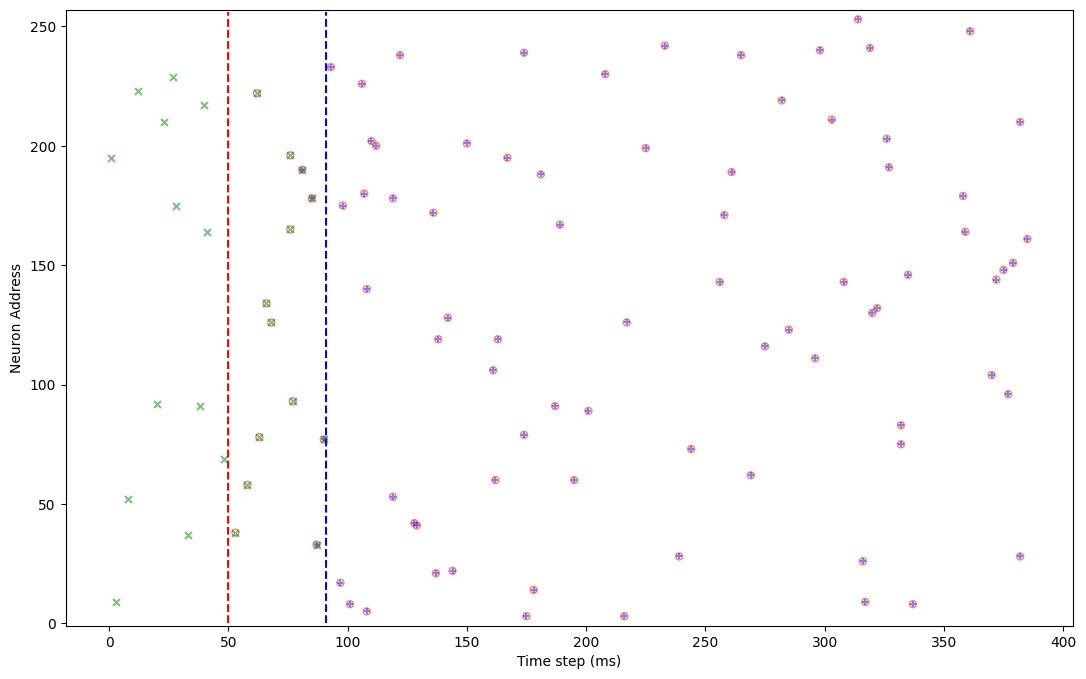

In [6]:
fig,ax = plt.subplots(figsize=(13, 8))
splt.raster(spikes[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="blue", marker='+', alpha=.5)
splt.raster(target_full[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
spikes.shape, spikes[i_SM, :, :].sum().item(), hd.target[i_SM, :, :].sum().item()

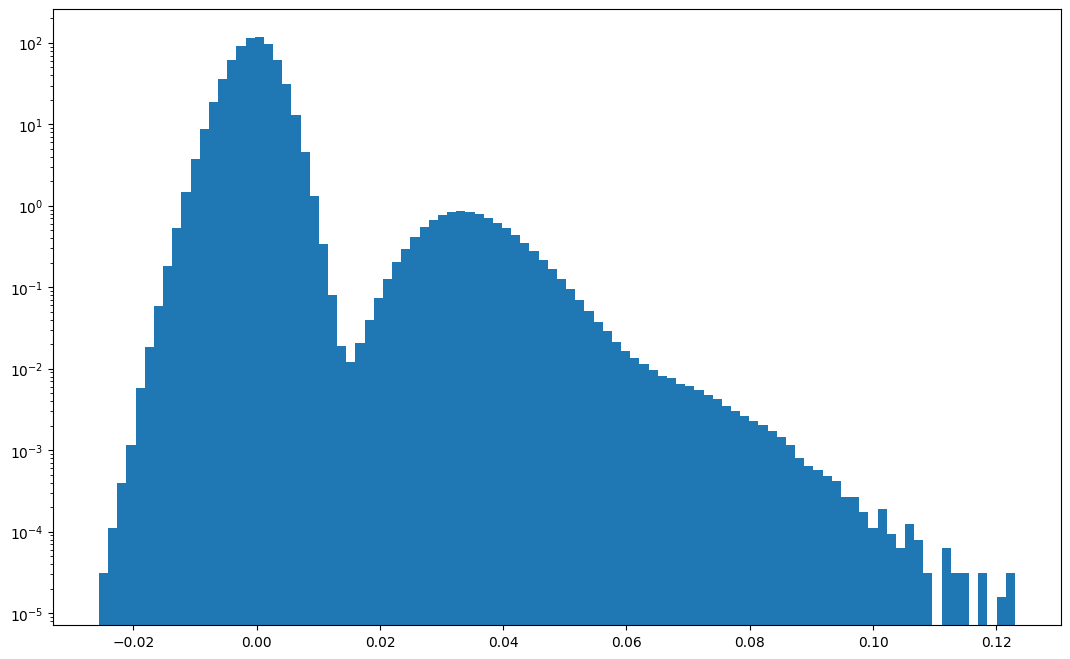

In [7]:
# hd.net.lin.bias.cpu().detach().numpy()
fig,ax = plt.subplots(figsize=(13, 8))
ax.hist(hd.net.lin.weight.cpu().detach().numpy().ravel(), bins=100, density=True) # pyright: ignore[reportCallIssue, reportAttributeAccessIssue]
ax.set_yscale('log')

## Retrieve a periodic memory

In [8]:
with torch.no_grad():
    target_full = torch.nn.functional.pad(hd.target, (opt.N_pretime, opt.N_pretime))
    input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=hd.opt.N_pretime, N_trigger_time=hd.opt.num_delay)
    _, _, spikes = hd.forward_pass(input_spikes)
    spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    target_evoked = hd.target[:, :, hd.opt.num_delay:]

    precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

precision = 1.000	 recall = 1.000	 f1_score = 1.000 
